In [5]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
from attr import dataclass
from typing import List
import torch
import pytorch_lightning as pl
import scanpy as sc
import numpy as np
import pandas as pd
import time
from torch.utils.data import DataLoader, TensorDataset
from sclead.model import TrainWrapperCLIPStyle
from sclead.dataset import H5ADDataset, LOG1PTransform, TotalSumNormalize
from sclead.utils import predict_with_distance_weights, get_semantics_labels, get_latent_representations, load_cell_types_mapping, load_cell_types_info
# from sclmct.paths import DATA_DIR, MODELS_DIR, RESULTS_DIR, CONFIGS_DIR
SEED = 1
@dataclass
class Args:
    # IO & data
    # data_dir: str
    save_root: str = "./results"
    ols_mappings_file: str = "./cell_type_data/cell_name_to_ols_id.json"
    ct_description_file: str = "./cell_type_data/cell_types_info_v1_full.json"
    use_parquet: bool = True

    # Model / training
    text_encoder_model: str = "michiyasunaga/BioLinkBERT-base"
    n_cell_layers: int = 5
    n_text_layers_to_finetune: int = 1
    n_prompts: int = 5
    pool_type: str = "mean"
    hidden_dim: int = 768
    use_projection_head: bool = False

    # Loss / logits hyperparams
    s: float = 30.0
    m1: float = 1.0
    m2: float = 0.3
    m3: float = 0.1
    m4: float = 1.5
    f_gamma: float = 1.3
    l_ct: float = 1.0
    l_tt: float = 0.1
    l_contrastive: float = 0.1
    l_graph: float = 0.1


    # Training setup
    seed: int = 1
    max_epoch: int = 200
    gradient_clip_val: float = 1.0

    # Execution
    parallel: bool = True
    workers: int = 8
    gpu_id: int = 0  # index into CUDA_VISIBLE_DEVICES

    # Eval / aux
    classifier: str = "faiss"

args = Args()



In [6]:

train_file_path = '/home/dungp/scLEAD/data/left_lung/train.h5ad'
test_file_path = '/home/dungp/scLEAD/data/left_lung/test.h5ad'
# file_size_gb = os.path.getsize(train_file_path) / (1024 ** 3)
# print(f"Train file size: {file_size_gb:.2f} GB")

train_adata = sc.read(train_file_path)
test_adata = sc.read(test_file_path)
cell_type_col = 'cell_type'

## data normalization
if train_adata.X.max() > 20:
    sc.pp.normalize_total(train_adata, target_sum=1e4)
    sc.pp.log1p(train_adata)
if test_adata.X.max() > 20:
    sc.pp.normalize_total(test_adata, target_sum=1e4)
    sc.pp.log1p(test_adata)

train_adata.obs[cell_type_col] = train_adata.obs[cell_type_col].str.lower().replace('_', ' ')
test_adata.obs[cell_type_col] = test_adata.obs[cell_type_col].str.lower().replace('_', ' ')

ols_mappings = load_cell_types_mapping()
label_prompts = load_cell_types_info()

train_label_dict = {ct:i for i, ct in enumerate(train_adata.obs[cell_type_col].unique())}


train_ds = TensorDataset(torch.tensor(train_adata.X.A if isinstance(train_adata.X, np.ndarray) else train_adata.X.toarray(), dtype=torch.float32),
                        torch.tensor(train_adata.obs[cell_type_col].map(train_label_dict).values, dtype=torch.long))


semantics_labels = get_semantics_labels(train_label_dict, ols_mappings)


In [7]:

print("train_label_dict len:", len(train_label_dict))
print("semantics_labels len:", len(semantics_labels))
print("train ids:", sorted(train_label_dict.values()))
print("semantic ids:", sorted(semantics_labels.keys()))

missing = set(train_label_dict.values()) - set(semantics_labels.keys())
extra = set(semantics_labels.keys()) - set(train_label_dict.values())

print("missing semantic ids:", missing)
print("extra semantic ids:", extra)


train_label_dict len: 8
semantics_labels len: 8
train ids: [0, 1, 2, 3, 4, 5, 6, 7]
semantic ids: [0, 1, 2, 3, 4, 5, 6, 7]
missing semantic ids: set()
extra semantic ids: set()


In [8]:

batch_size = 256
g = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True,
                            worker_init_fn=lambda i: np.random.seed(SEED+i), generator=g)

## path to save the Text encoder cache (output of the second-to-last layer)
cache_path = os.path.join("./cache/cached_prompt_embeddings.pt")
## remove if cache exists
if os.path.exists(cache_path):
    os.remove(cache_path)
if not os.path.exists(os.path.dirname(cache_path)):
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
D_input = next(iter(train_loader))[0].shape[-1]


 ## read the graph embeddings

## dataframe with columns "name" "cell_label" "embedding"
# data = np.load("./extracted_embeddings/graph_node_embs.npz", allow_pickle=True)
data = np.load('../data/graph_embeddings/cl_poincare_embeddings.npz', allow_pickle=True)
names = data["names"]            # shape: [N]
embeddings = data["embeddings"]  # shape: [N, D], float32
# optional: build a lookup dict
name_to_idx = {name.lower(): i for i, name in enumerate(names)}

## get graph embeddings for only the training cells
graph_embeddings = np.zeros((len(train_label_dict), embeddings.shape[1]), dtype=np.float32)
for cell_ols_id, int_idx in train_label_dict.items():
    if cell_ols_id in name_to_idx:
        graph_embeddings[int_idx] = embeddings[name_to_idx[cell_ols_id]]

print("Embeddings for training cells shape:", graph_embeddings.shape)



# Peek feature dimension from one batch
first_batch = next(iter(train_loader))
if isinstance(first_batch[0], dict):
    d_input = first_batch[0]["X"].shape[-1]
else:
    d_input = first_batch[0].shape[-1]

model = TrainWrapperCLIPStyle(
    input_dim=d_input,
    hidden_dim=args.hidden_dim,
    output_dim=None,
    label_prompts=semantics_labels,
    n_cell_layers=args.n_cell_layers,
    text_encoder_model=args.text_encoder_model,
    use_projection_head=args.use_projection_head,
    n_prompts=args.n_prompts,
    pool_type=args.pool_type,
    n_text_layers_to_finetune=args.n_text_layers_to_finetune,
    device="cuda",
    cache_path=cache_path,
    lr=1e-4,
    weight_decay=1e-4,
    s=args.s,
    m1=args.m1,
    m2=args.m2,
    m3=args.m3,
    m4=args.m4,
    f_gamma=args.f_gamma,
    l_ct=args.l_ct,
    l_tt=args.l_tt,
    l_contrastive=args.l_contrastive,
    l_graph=args.l_graph,
    graph_embeddings=graph_embeddings
)

callbacks = [
    pl.callbacks.EarlyStopping(monitor="train_loss", patience=5, min_delta=0.001),
    pl.callbacks.ModelCheckpoint(dirpath=os.path.join("./results", "checkpoints"),
                                monitor="train_loss", save_top_k=1, mode="min")
]

trainer = pl.Trainer(
    max_epochs=args.max_epoch,
    accelerator="gpu",
    devices=[0],
    callbacks=callbacks,
    gradient_clip_val=1.0,
    deterministic=True,
)

start = time.time()
trainer.fit(model, train_loader)
model = TrainWrapperCLIPStyle.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)
print(f"Training finished in {time.time() - start:.2f} seconds.")

Embeddings for training cells shape: (8, 50)
[INFO] Loaded model with 12 transformer layers.
[INFO] No projection_dim provided, using hidden_size as projection_dim.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/dungp/miniconda3/envs/sclead/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:701: Checkpoint directory /home/dungp/scLEAD/analyses/within_tissue_annotation/results/checkpoints exists and is not empty.


[INFO] Generating prompt cache...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name                      | Type                    | Params | Mode 
------------------------------------------------------------------------------
0 | text_encoder_wrapper      | TextEncoderWrapper      | 108 M  | train
1 | encoder                   | CellEncoder             | 44.3 M | train
2 | loss_cell_text            | LabelAwareMarginLoss    | 0      | train
3 | text_center_loss          | RepelContrastiveLoss    | 1      | train
4 | permuted_contrastive_loss | PermutedContrastiveLoss | 0      | train
5 | graph_loss                | GraphLoss               | 0      | train
------------------------------------------------------------------------------
51.4 M    Trainable params
101 M     Non-trainable params
152 M     Total params
610.004   Total estimated model params size (MB)
54        Modules in train mode
228       Modules in eval mode
/home/dungp/miniconda3/envs/sclead/lib/python3.10/site-packages/pytorch_lightning/trainer/conne

[INFO] Saved prompt cache to ./cache/cached_prompt_embeddings.pt
Epoch 13: 100%|██████████| 27/27 [00:06<00:00,  4.26it/s, v_num=9, train_loss=0.0016, loss_cell_text=2.1e-5, loss_text_text=2.05e-5, loss_permuted=0.0158, graph_loss=0.000]   
[INFO] Loaded model with 12 transformer layers.
[INFO] No projection_dim provided, using hidden_size as projection_dim.
Training finished in 88.99 seconds.


## Loading new data

In [9]:
os.listdir("../")

['zero_shot_annotation', 'cell_clustering', 'within_tissue_annotation', 'data']

In [10]:

train_lat = get_latent_representations(
        train_adata.X.A if isinstance(train_adata.X, np.ndarray) else train_adata.X.toarray(),
        model = model,
        batch_size=256,
        device = "cuda"
    )

test_lat = get_latent_representations(
    test_adata.X.A if isinstance(test_adata.X, np.ndarray) else test_adata.X.toarray(),
    model = model,
    batch_size=256,
    device = "cuda"
)
train_labels = train_adata.obs[cell_type_col].values
test_labels = test_adata.obs[cell_type_col].values

In [11]:
## KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn = KNeighborsClassifier(n_neighbors=11, weights='distance', metric='cosine')
knn.fit(train_lat, train_labels)
test_pred = knn.predict(test_lat)

print(classification_report(test_labels, test_pred, digits=2))

                                      precision    recall  f1-score   support

                              b cell       1.00      0.99      1.00       195
       blood vessel endothelial cell       0.95      1.00      0.98       121
endothelial cell of lymphatic vessel       0.00      0.00      0.00         5
                     epithelial cell       1.00      0.99      1.00       308
                          fibroblast       0.97      1.00      0.99        36
                        myeloid cell       0.77      1.00      0.87       304
                          neutrophil       0.00      0.00      0.00        89
                              t cell       1.00      1.00      1.00      1078

                            accuracy                           0.95      2136
                           macro avg       0.71      0.75      0.73      2136
                        weighted avg       0.92      0.95      0.93      2136



/home/dungp/miniconda3/envs/sclead/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dungp/miniconda3/envs/sclead/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dungp/miniconda3/envs/sclead/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

### Visualization

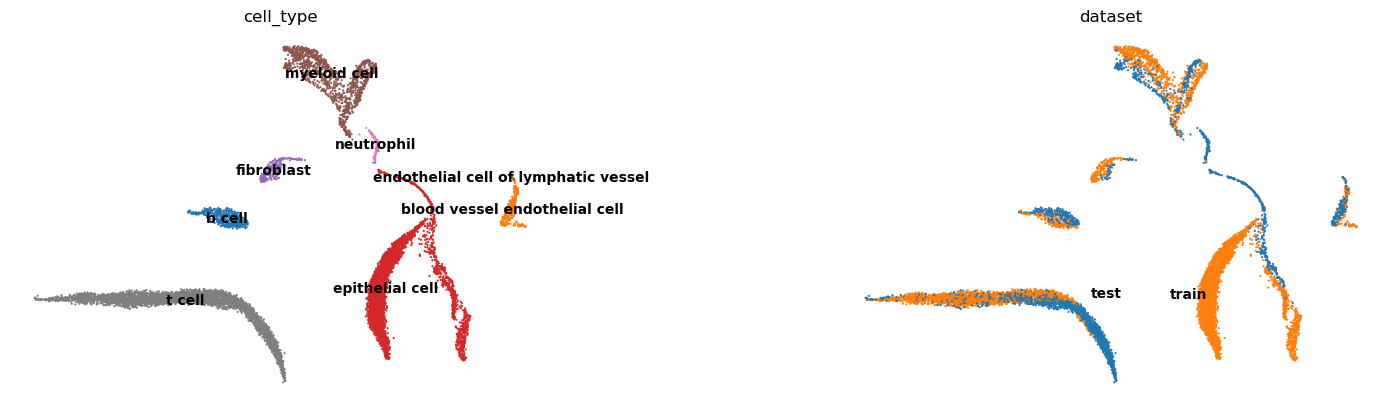

In [12]:
## plot both train and test
plot_adata = sc.AnnData(np.concatenate([train_lat, test_lat], axis=0))
obs_df = pd.DataFrame({
    'cell_type': np.concatenate([train_labels, test_labels], axis=0),
    'dataset': ['train'] * len(train_labels) + ['test'] * len(test_labels)
})
plot_adata.obs = obs_df
sc.pp.neighbors(plot_adata, use_rep='X')
sc.tl.umap(plot_adata)
sc.pl.umap(plot_adata, color=['cell_type', 'dataset'], wspace=0.4, size=10, frameon=False, legend_loc='on data', show=True)
